# Home assignment: PCA, t-SNE and UMAP on molecular descriptors



In [1]:
# Uncomment on Google Colab
# !pip install rdkit umap-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
except ImportError:
    raise ImportError("RDKit is missing. Install it with:  pip install rdkit")

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
    print("umap-learn not found; UMAP cells will be skipped. Install with: pip install umap-learn")

SEED = 42

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Build a small molecule dataset
Six chemical classes, generated systematically so every SMILES is valid.

In [3]:
def build_dataset():
    rows = []

    def add(smiles, cls):
        rows.append({"smiles": smiles, "class": cls})

    for n in range(1, 11):
        add("C" * n + "O", "Alcohol")
    for m in range(1, 6):
        add("CC(O)" + "C" * m, "Alcohol")

    for n in range(1, 11):
        add("C" * n + "N", "Amine")
    for m in range(1, 6):
        add("CN(C)" + "C" * m, "Amine")

    for n in range(0, 10):
        add("C" * n + "C(=O)O", "Carboxylic acid")
    for m in range(1, 6):
        add("OC(=O)" + "C" * m + "C(=O)O", "Carboxylic acid")

    for n in range(1, 11):
        add("CC(=O)" + "C" * n, "Ketone")

    for n in range(1, 9):
        add("C" * n + "Cl", "Haloalkane")
    for n in range(1, 8):
        add("C" * n + "Br", "Haloalkane")

    for n in range(0, 10):
        add("c1ccccc1" + "C" * n, "Aromatic")
    for s in ["Cc1ccc(C)cc1", "Cc1cccc(C)c1", "c1ccc2ccccc2c1",
              "c1ccc(cc1)-c1ccccc1", "c1ccc2cc3ccccc3cc2c1"]:
        add(s, "Aromatic")

    return pd.DataFrame(rows)


def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "MolMR": Crippen.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "AromRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FracCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
    }


df = build_dataset()
desc = pd.DataFrame([compute_descriptors(s) for s in df["smiles"]])
data = pd.concat([df, desc], axis=1)
feature_cols = list(desc.columns)
X_raw = data[feature_cols].to_numpy(dtype=float)

print(f"{len(data)} molecules, {len(feature_cols)} descriptors")
print(data["class"].value_counts())
data.head()

85 molecules, 11 descriptors
class
Alcohol            15
Amine              15
Carboxylic acid    15
Haloalkane         15
Aromatic           15
Ketone             10
Name: count, dtype: int64


,smiles,class,MolWt,LogP,MolMR,TPSA,HBD,HBA,RotBonds,Rings,AromRings,FracCSP3,HeavyAtoms
0,CO,Alcohol,32.042,-0.3915,8.1428,20.23,1,1,0,0,0,1.0,2
1,CCO,Alcohol,46.069,-0.0014,12.7598,20.23,1,1,0,0,0,1.0,3
2,CCCO,Alcohol,60.096,0.3887,17.3768,20.23,1,1,1,0,0,1.0,4
3,CCCCO,Alcohol,74.123,0.7788,21.9938,20.23,1,1,2,0,0,1.0,5
4,CCCCCO,Alcohol,88.150,1.1689,26.6108,20.23,1,1,3,0,0,1.0,6


## 2. Plotting helper

In [4]:
CLASSES = sorted(data["class"].unique())
MARKERS = ["o", "^", "s", "D", "v", "P"]
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#6250d6"]


def plot_by_class(ax, Y, title, xlabel="Dim 1", ylabel="Dim 2"):
    for cls, mk, col in zip(CLASSES, MARKERS, COLORS):
        idx = (data["class"] == cls).to_numpy()
        ax.scatter(Y[idx, 0], Y[idx, 1], marker=mk, c=col, s=35,
                   edgecolor="white", linewidth=0.5, label=cls)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def plot_by_value(ax, Y, values, title, label):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=values, cmap="viridis", s=35,
                    edgecolor="white", linewidth=0.5)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(title, fontsize=10)

## 3. PCA: raw vs standardized descriptors

Explained variance ratio (raw):          [0.8178 0.1704 0.0106 0.0011]
Explained variance ratio (standardized): [0.4828 0.2881 0.174  0.0224]


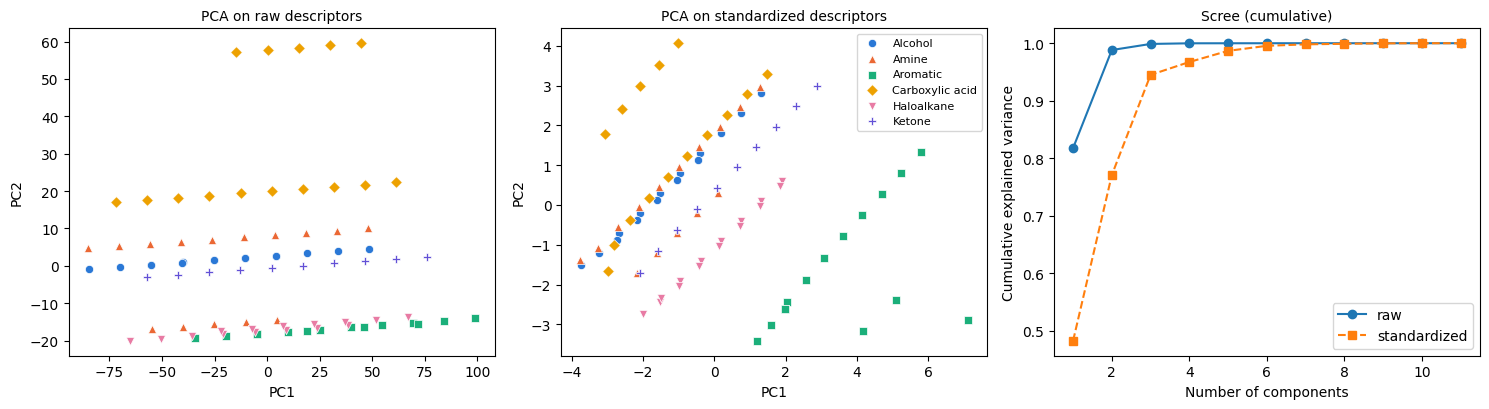

In [5]:
X_std = StandardScaler().fit_transform(X_raw)

pca_raw = PCA().fit(X_raw - X_raw.mean(axis=0))
pca_std = PCA().fit(X_std)

print("Explained variance ratio (raw):         ", np.round(pca_raw.explained_variance_ratio_[:4], 4))
print("Explained variance ratio (standardized):", np.round(pca_std.explained_variance_ratio_[:4], 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
Y_raw = pca_raw.transform(X_raw - X_raw.mean(axis=0))[:, :2]
Y_pca = pca_std.transform(X_std)[:, :2]
plot_by_class(axes[0], Y_raw, "PCA on raw descriptors", "PC1", "PC2")
plot_by_class(axes[1], Y_pca, "PCA on standardized descriptors", "PC1", "PC2")

k = np.arange(1, len(feature_cols) + 1)
axes[2].plot(k, np.cumsum(pca_raw.explained_variance_ratio_), "o-", label="raw")
axes[2].plot(k, np.cumsum(pca_std.explained_variance_ratio_), "s--", label="standardized")
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Cumulative explained variance")
axes[2].set_title("Scree (cumulative)", fontsize=10)
axes[2].legend()
axes[1].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("fig1_pca.png", dpi=150)
plt.show()

### PCA loadings (standardized)

In [6]:
loadings = pd.DataFrame(pca_std.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
print(loadings.round(3).sort_values("PC1", key=abs, ascending=False))

              PC1    PC2
LogP        0.404  0.116
MolMR       0.389  0.239
HeavyAtoms  0.355  0.297
MolWt       0.348  0.295
Rings       0.319 -0.246
AromRings   0.319 -0.246
HBA        -0.252  0.360
HBD        -0.231  0.320
TPSA       -0.211  0.360
FracCSP3   -0.195  0.205
RotBonds    0.187  0.480


### YOUR TURN (B1)
1. Why does raw-data PCA give a very high PC1 explained variance? Which descriptor dominates?
2. Using the loadings, give a chemical name to PC1 and PC2 of the standardized PCA.
3. How many components are needed to reach 90% of the variance (standardized)?

In [7]:
n90 = int(np.searchsorted(np.cumsum(pca_std.explained_variance_ratio_), 0.90) + 1)
print("Components needed for 90% variance (standardized):", n90)

Components needed for 90% variance (standardized): 3


In [8]:
# Supporting evidence for B1: variance of each raw descriptor and raw-PCA loadings
print("Variance of raw descriptors:")
print(pd.Series(X_raw.var(axis=0, ddof=1), index=feature_cols).sort_values(ascending=False).round(2))
raw_load = pd.DataFrame(pca_raw.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
print("\nRaw-PCA loadings:")
print(raw_load.round(3).sort_values("PC1", key=abs, ascending=False))

Variance of raw descriptors:
MolWt         1623.24
TPSA           372.21
MolMR          184.52
HeavyAtoms       9.65
RotBonds         6.73
LogP             1.59
HBD              0.37
HBA              0.33
Rings            0.29
AromRings        0.29
FracCSP3         0.09
dtype: float64

Raw-PCA loadings:
              PC1    PC2
MolWt       0.949  0.067
MolMR       0.301 -0.083
HeavyAtoms  0.067  0.018
RotBonds    0.048  0.035
TPSA       -0.041  0.992
LogP        0.026 -0.026
Rings       0.004 -0.010
AromRings   0.004 -0.010
HBD        -0.003  0.028
HBA        -0.003  0.025
FracCSP3   -0.001  0.000


### Answers (B1)

**1. Why is PC1 so dominant on raw data?**
PCA finds the directions of largest variance, and on unscaled data variance depends on each descriptor's **units**. **MolWt** is in g/mol (roughly 30–250 here) and has a variance of about **1620**, far above every other descriptor (TPSA ≈ 372, MolMR ≈ 185, and everything else < 10). So PC1 is almost exactly the MolWt axis (loading ≈ **0.95**, with MolMR ≈ 0.30 next) and takes **81.8 %** of the variance. PC2 (17.0 %) is almost pure **TPSA** (loading ≈ 0.99), which is why the raw plot shows horizontal bands by polarity: carboxylic acids at the top (the diacids have the highest TPSA), then amines and alcohols, with haloalkanes and aromatics (TPSA = 0) at the bottom. Together the first two PCs reach 98.8 %. This does *not* mean the data is almost 1-D. It only reflects the scale of the numbers. Descriptors such as HBD, Rings, AromRings and FracCSP3 are effectively ignored.

**2. Chemical meaning of the standardized PCs**
- **PC1 (48.3 %) = molecular size / lipophilicity axis.** It has large positive loadings for LogP (0.40), MolMR (0.39), HeavyAtoms (0.36), MolWt (0.35) and Rings/AromRings (0.32), and negative loadings for HBA, HBD, TPSA and FracCSP3. High PC1 means big, hydrophobic, often aromatic molecules. Low PC1 means small, polar, saturated molecules.
- **PC2 (28.8 %) = polarity / flexibility vs. aromaticity axis.** It has large positive loadings for RotBonds (0.48), HBA (0.36), TPSA (0.36) and HBD (0.32), and negative loadings for Rings/AromRings (−0.25). High PC2 means flexible, H-bonding, polar molecules (acids, alcohols, amines). Low PC2 means rigid aromatic rings and non-polar haloalkanes.

In the standardized plot, each class appears as a diagonal line (a homologous series moves along PC1 and PC2 as the chain grows), with the lines offset by their functional group. Aromatics sit in the lower right and acids in the upper left.

**3. Components for 90 % variance (standardized): 3**
The cumulative values are 48.3 % → 77.1 % → **94.5 %**. PC3 (17.4 %) is needed to get past 90 %. On raw data 2 PCs would already be enough, which is misleading for the reason given in (1).

## 4. t-SNE: effect of perplexity and random seed

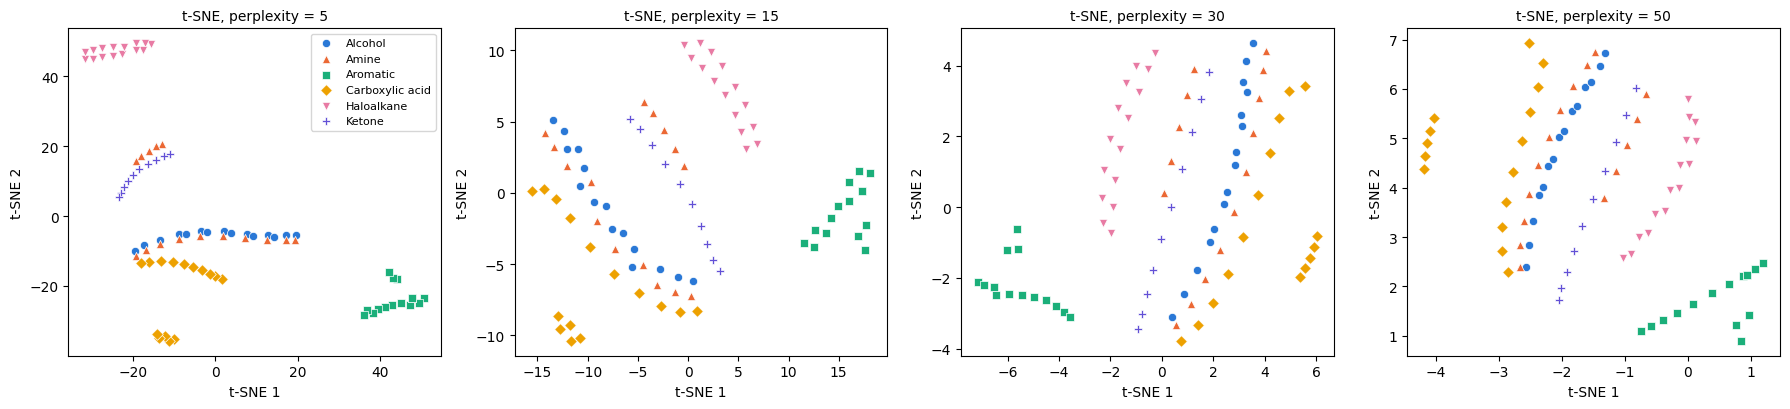

In [9]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 4.2))
tsne_results = {}
for ax, p in zip(axes, perplexities):
    Y = TSNE(n_components=2, perplexity=p, init="pca", learning_rate="auto",
             random_state=SEED).fit_transform(X_std)
    tsne_results[p] = Y
    plot_by_class(ax, Y, f"t-SNE, perplexity = {p}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig2_tsne_perplexity.png", dpi=150)
plt.show()

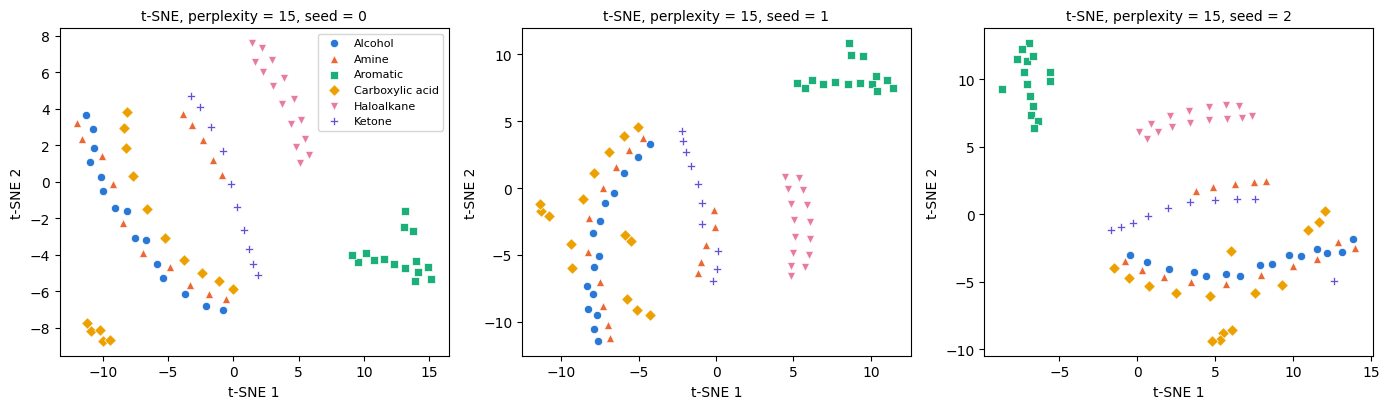

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, seed in zip(axes, [0, 1, 2]):
    Y = TSNE(n_components=2, perplexity=15, init="random", learning_rate="auto",
             random_state=seed).fit_transform(X_std)
    plot_by_class(ax, Y, f"t-SNE, perplexity = 15, seed = {seed}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig3_tsne_seeds.png", dpi=150)
plt.show()

### YOUR TURN (B2)
1. How does the map change as perplexity increases from 5 to 50?
2. Which features stay the same across seeds, and which change?
3. Why is perplexity = 100 not allowed for this dataset?

In [11]:
# B2.3 demonstration: perplexity must be smaller than the number of samples
try:
    TSNE(n_components=2, perplexity=100, random_state=SEED).fit_transform(X_std)
except ValueError as e:
    print("ValueError:", e)

ValueError: perplexity (100) must be less than n_samples (85)


### Answers (B2)

**1. Effect of perplexity (5 → 50)**
Perplexity is roughly the effective number of neighbours each point takes into account.
- **Perplexity 5:** very local. Each homologous series becomes a tight, separate string, and gaps between groups are large (axis range about ±50). Small sub-groups split off. For example, the 5 diacids form their own island apart from the monoacids, and the aromatics break into sub-clusters. Some classes that are chemically alike, such as alcohols and amines, lie on top of each other.
- **Perplexity 15–30:** a balance. Every class is still a coherent curve, and similar classes (alcohol / amine / carboxylic acid, the polar H-bond donors) move close together, while aromatics and haloalkanes stay separate.
- **Perplexity 50:** more global. The map contracts (axis range only a few units), clusters are less separated and start to merge into one large cloud, and the overall layout looks more like PCA (aromatics on one side, acids on the other). Fine local detail is lost.

**2. What is stable across seeds (with random init)?**
- *Stable:* which points are neighbours of which. Each homologous series stays a continuous chain ordered by chain length. Aromatics and haloalkanes are always their own well-separated clusters, alcohols and amines always overlap, and the diacids always form a small separate group.
- *Changes:* absolute position, rotation and reflection of the whole map; where the clusters sit relative to each other; the distances between clusters; and the shape of the chains (straight, bent, or folded). So distances *between* clusters and axis directions in t-SNE carry no meaning. Only local neighbourhoods can be interpreted.

**3. Why is perplexity = 100 not allowed?**
The dataset has only **85 molecules**. Perplexity sets the effective number of neighbours for each point, so it cannot exceed the number of *other* points available (84). scikit-learn requires `perplexity < n_samples` and raises `ValueError: perplexity (100) must be less than n_samples (85)` (demonstrated in the cell above). A rule of thumb is to keep perplexity well below N/3, because the neighbour search uses about 3 × perplexity points.

## 5. UMAP: effect of n_neighbors and min_dist

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


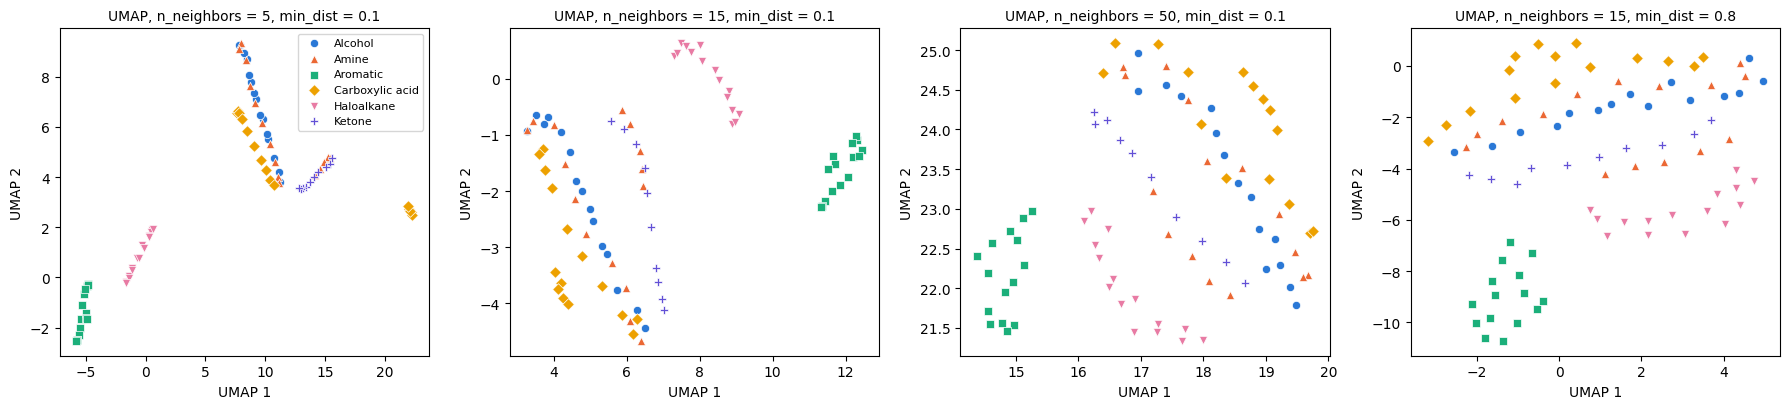

In [12]:
umap_results = {}
if HAVE_UMAP:
    settings = [(5, 0.1), (15, 0.1), (50, 0.1), (15, 0.8)]
    fig, axes = plt.subplots(1, len(settings), figsize=(18, 4.2))
    for ax, (nn, md) in zip(axes, settings):
        Y = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=SEED).fit_transform(X_std)
        umap_results[(nn, md)] = Y
        plot_by_class(ax, Y, f"UMAP, n_neighbors = {nn}, min_dist = {md}", "UMAP 1", "UMAP 2")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("fig4_umap.png", dpi=150)
    plt.show()

### YOUR TURN (B3)
1. Compare n_neighbors = 5 and 50. Which shows more local detail, which more global layout?
2. What does increasing min_dist from 0.1 to 0.8 do to the clusters?

### Answers (B3)

**1. n_neighbors = 5 vs 50**
- **n_neighbors = 5 → more local detail.** UMAP builds its graph from very small neighbourhoods, so each homologous series becomes a thin, sharp line and the classes break into separate islands (aromatics, haloalkanes, monoacids, diacids, ketones). The positions of the islands relative to each other are fairly arbitrary, and the groups are disconnected.
- **n_neighbors = 50 → more global layout.** Each point considers more than half the dataset, so the embedding keeps large-scale structure: one connected layout in which aromatics sit at one end, haloalkanes next to them, and the polar classes (alcohols, amines, acids, ketones) together. This ordering is closer to the PCA picture. The cost is that local structure blurs and the chains become noisier and overlap more.
- n_neighbors = 15 falls in between.

**2. min_dist 0.1 → 0.8**
`min_dist` controls how tightly UMAP is allowed to pack points in the 2D map. At 0.8, points are pushed apart, so clusters become **larger, more diffuse and evenly spread**. The sharp line-like homologous series swell into loose bands, and the gaps between classes shrink. Classes such as alcohol/amine/acid/ketone become interleaved stripes, and only the aromatics stay clearly separate. The neighbour graph (topology) is the same. Only the visual compactness changes, so a small min_dist suits cluster finding and a large one suits seeing the overall spread.

## 6. Colour by a continuous property

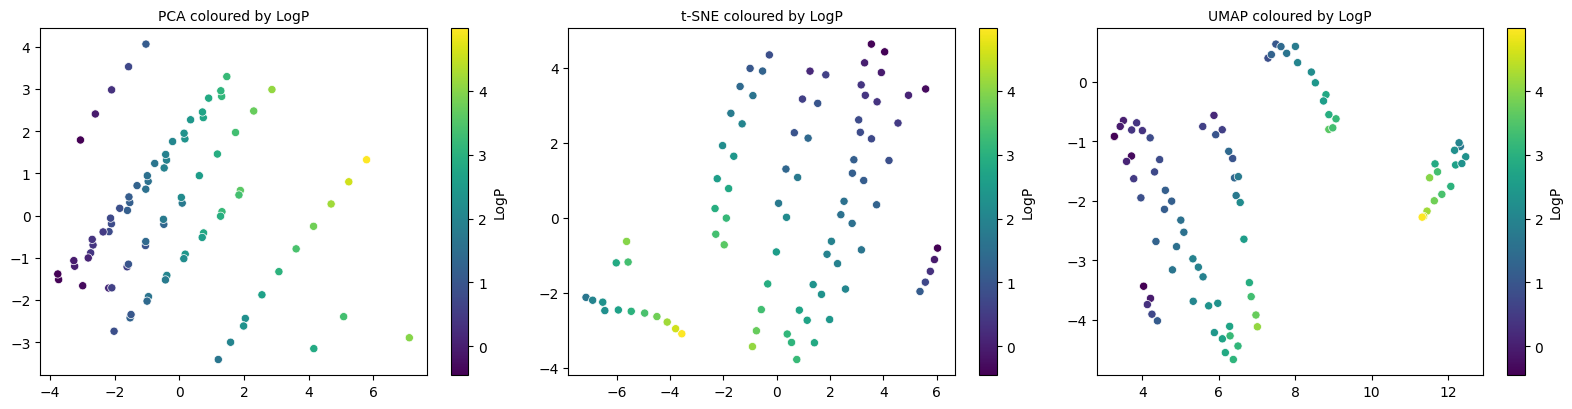

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_by_value(axes[0], Y_pca, data["LogP"], "PCA coloured by LogP", "LogP")
plot_by_value(axes[1], tsne_results[30], data["LogP"], "t-SNE coloured by LogP", "LogP")
if HAVE_UMAP:
    plot_by_value(axes[2], umap_results[(15, 0.1)], data["LogP"], "UMAP coloured by LogP", "LogP")
else:
    axes[2].axis("off")
plt.tight_layout()
plt.savefig("fig5_logp.png", dpi=150)
plt.show()

### YOUR TURN (B4)
Inside each class cluster, is there a smooth LogP gradient? What structural change
(hint: chain length) produces it?

### Answers (B4)

**Yes. Inside every class there is a smooth, monotonic LogP gradient.** In all three maps each class appears as a string or line, and the colour changes steadily from dark (low LogP) at one end to yellow/green (high LogP) at the other.

**Cause: chain length (homologous series).** Each class was built by adding CH₂ units one at a time (methanol → ethanol → propanol …, benzene → toluene → ethylbenzene …). Every extra CH₂ adds about **+0.39 LogP units** in Crippen's scheme (e.g. MeOH −0.39, EtOH 0.00, PrOH 0.39, BuOH 0.78), together with a matching rise in MolWt, MolMR, HeavyAtoms and RotBonds. Because all of these descriptors grow together, each series follows a nearly straight path in descriptor space, and the dimensionality-reduction methods keep that path as a string with a colour gradient along it.

- **PCA:** the gradient lies along parallel diagonals, and LogP rises mainly with PC1 (LogP has the largest PC1 loading, 0.40). Across classes, the functional group sets the starting point: acids and diacids start lowest, aromatics and long haloalkanes reach LogP ≈ 4–5.
- **t-SNE / UMAP:** the gradient is preserved *within* each string, but t-SNE/UMAP do not keep a single global LogP direction. Strings point in arbitrary directions, so LogP cannot be read off one axis.
- Exceptions to a perfectly smooth trend are the branched or isomeric members (e.g. the 2-alkanols, N,N-dimethylamines, xylene isomers and fused rings such as naphthalene/anthracene). They sit slightly off their series' main line.

## 7. Quantitative comparison: trustworthiness
Trustworthiness (0 to 1) measures how well each point's nearest neighbours in the map
were also neighbours in the original space. 1 means perfect local preservation.

In [14]:
emb = {"PCA (2 PCs)": Y_pca, "t-SNE (perp 30)": tsne_results[30]}
if HAVE_UMAP:
    emb["UMAP (nn 15)"] = umap_results[(15, 0.1)]

for k_nn in [5, 15]:
    for name, Y in emb.items():
        t = trustworthiness(X_std, Y, n_neighbors=k_nn)
        print(f"k = {k_nn:2d}  {name:18s} trustworthiness = {t:.3f}")

k =  5  PCA (2 PCs)        trustworthiness = 0.986
k =  5  t-SNE (perp 30)    trustworthiness = 0.996
k =  5  UMAP (nn 15)       trustworthiness = 0.981
k = 15  PCA (2 PCs)        trustworthiness = 0.981
k = 15  t-SNE (perp 30)    trustworthiness = 0.971
k = 15  UMAP (nn 15)       trustworthiness = 0.937


### YOUR TURN (B5)
1. Which method preserves local neighbourhoods best? Is that what you expected?
2. Trustworthiness says nothing about distances between clusters. Propose a check
   for global structure (hint: correlate pairwise distances in the original and 2D spaces).

PCA (2 PCs)        Spearman rho = 0.954   Pearson r = 0.957
t-SNE (perp 30)    Spearman rho = 0.866   Pearson r = 0.799
UMAP (nn 15)       Spearman rho = 0.758   Pearson r = 0.725


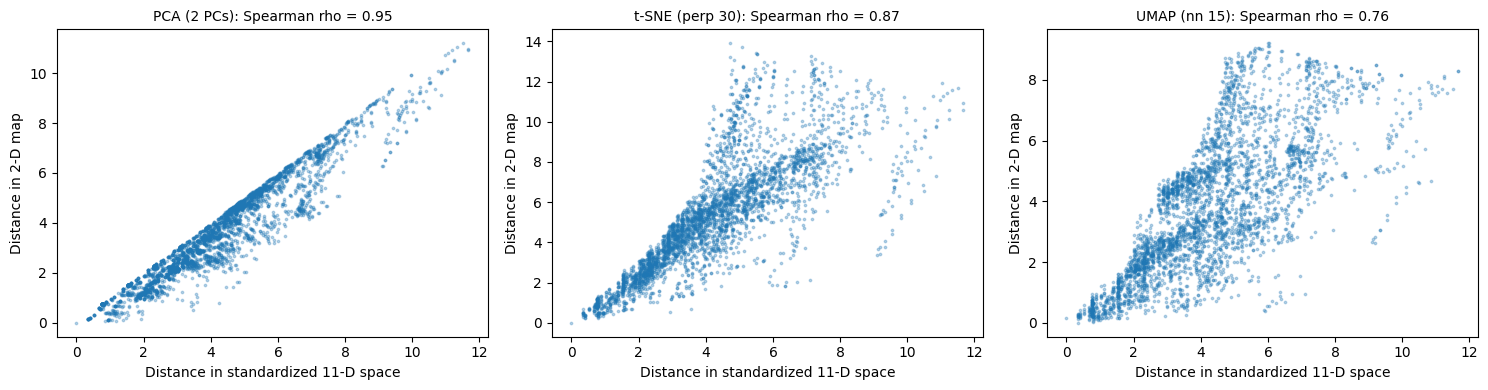

In [15]:
# B5.2: global-structure check - correlate all pairwise distances in the original
# (standardized) 11-D space with the pairwise distances in each 2-D map.
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, pearsonr

D_high = pdist(X_std)                      # 85*84/2 = 3570 pairwise distances
fig, axes = plt.subplots(1, len(emb), figsize=(5 * len(emb), 4))
for ax, (name, Y) in zip(np.atleast_1d(axes), emb.items()):
    D_low = pdist(Y)
    rho = spearmanr(D_high, D_low)[0]
    r = pearsonr(D_high, D_low)[0]
    print(f"{name:18s} Spearman rho = {rho:.3f}   Pearson r = {r:.3f}")
    ax.scatter(D_high, D_low, s=3, alpha=0.3)
    ax.set_xlabel("Distance in standardized 11-D space")
    ax.set_ylabel("Distance in 2-D map")
    ax.set_title(f"{name}: Spearman rho = {rho:.2f}", fontsize=10)
plt.tight_layout()
plt.savefig("fig6_distance_correlation.png", dpi=150)
plt.show()

### Answers (B5)

**1. Which method preserves local neighbourhoods best?**
| k | PCA (2 PCs) | t-SNE (perp 30) | UMAP (nn 15) |
|---|---|---|---|
| 5  | 0.986 | **0.996** | 0.981 |
| 15 | **0.981** | 0.971 | 0.937 |

- At the **most local scale (k = 5)**, **t-SNE is best** (0.996). This is expected: its objective only tries to keep each point's closest neighbours close.
- At **k = 15**, **PCA scores highest** and UMAP drops to 0.937. This is less expected but makes sense here. The standardized data is almost linear and low-dimensional (2 PCs already explain 77 %, 3 explain 94.5 %), so a linear projection keeps medium-range neighbourhoods well. t-SNE and UMAP tear the data into separate strings and islands, so neighbours at the 15-point scale can end up far apart.
- All scores are high (> 0.93), so every method is trustworthy at small scales on this simple, structured dataset. The general textbook ranking, where t-SNE/UMAP beat PCA locally, holds most clearly for small k, and less so for data that is nearly linear like this. Differences between UMAP and t-SNE also depend on the hyper-parameters and the seed.

**2. Checking global structure**
Trustworthiness only compares neighbour lists, so it cannot tell whether *clusters* are placed correctly relative to each other. A simple global check (run in the cell above):
1. Compute all N(N−1)/2 = 3570 pairwise Euclidean distances in the standardized 11-D space and in each 2-D embedding (`scipy.spatial.distance.pdist`).
2. Correlate the two sets of distances. **Spearman ρ** (rank-based) is the better choice because t-SNE/UMAP distort distances non-linearly, and Pearson r can be reported alongside. A Shepard diagram (the scatter of high-D vs 2-D distance) shows *where* distortion happens.

Results:
| Method | Spearman ρ | Pearson r |
|---|---|---|
| PCA (2 PCs) | **0.954** | **0.957** |
| t-SNE (perp 30) | 0.866 | 0.799 |
| UMAP (nn 15) | 0.758 | 0.725 |

**PCA preserves global geometry best**, as expected for a linear, variance-preserving projection. t-SNE and UMAP compress large distances and exaggerate gaps between clusters, so distances between clusters in those maps should not be interpreted. Other useful checks include this correlation computed on **class centroids** only, stability of cluster placement across seeds, and trustworthiness at large k (e.g. k = 40).